In [1]:
! pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.7 MB/s eta 0:00:0000:01


## Import Dependecies 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
from PIL import Image, ImageOps
import os
from pathlib import Path

import shutil

from sklearn.model_selection import train_test_split
import yaml

In [3]:
# Load CSV
df = pd.read_csv('/kaggle/input/datasets/martinkoome/shoe-annotation/shoe_annotations.csv')
unique_images = df['filename'].unique()
selected_images = random.sample(list(unique_images), 12)

In [4]:
len(unique_images)

146

In [5]:
df

,filename,image_width,image_height,class,xmin,ymin,width,height
0,shoe_110.jpeg,1200,1599,shoe,397,225,311,817
1,shoe_100.jpeg,1200,1599,shoe,110,561,950,395
2,shoe_102.jpeg,1200,1599,shoe,358,238,411,951
3,shoe_106.jpeg,1200,1599,shoe,358,129,387,846
4,shoe_104.jpeg,1200,1599,shoe,357,382,514,949
...,...,...,...,...,...,...,...,...
157,shoe_32.jpeg,1280,574,shoe,232,89,738,360
158,shoe_56.jpeg,1280,574,shoe,238,52,806,423
159,shoe_78.jpg,6936,9248,shoe,1280,3020,4564,2769
160,shoe_86.jpg,6936,9248,shoe,3014,3904,929,1004


## Visualize a sample 

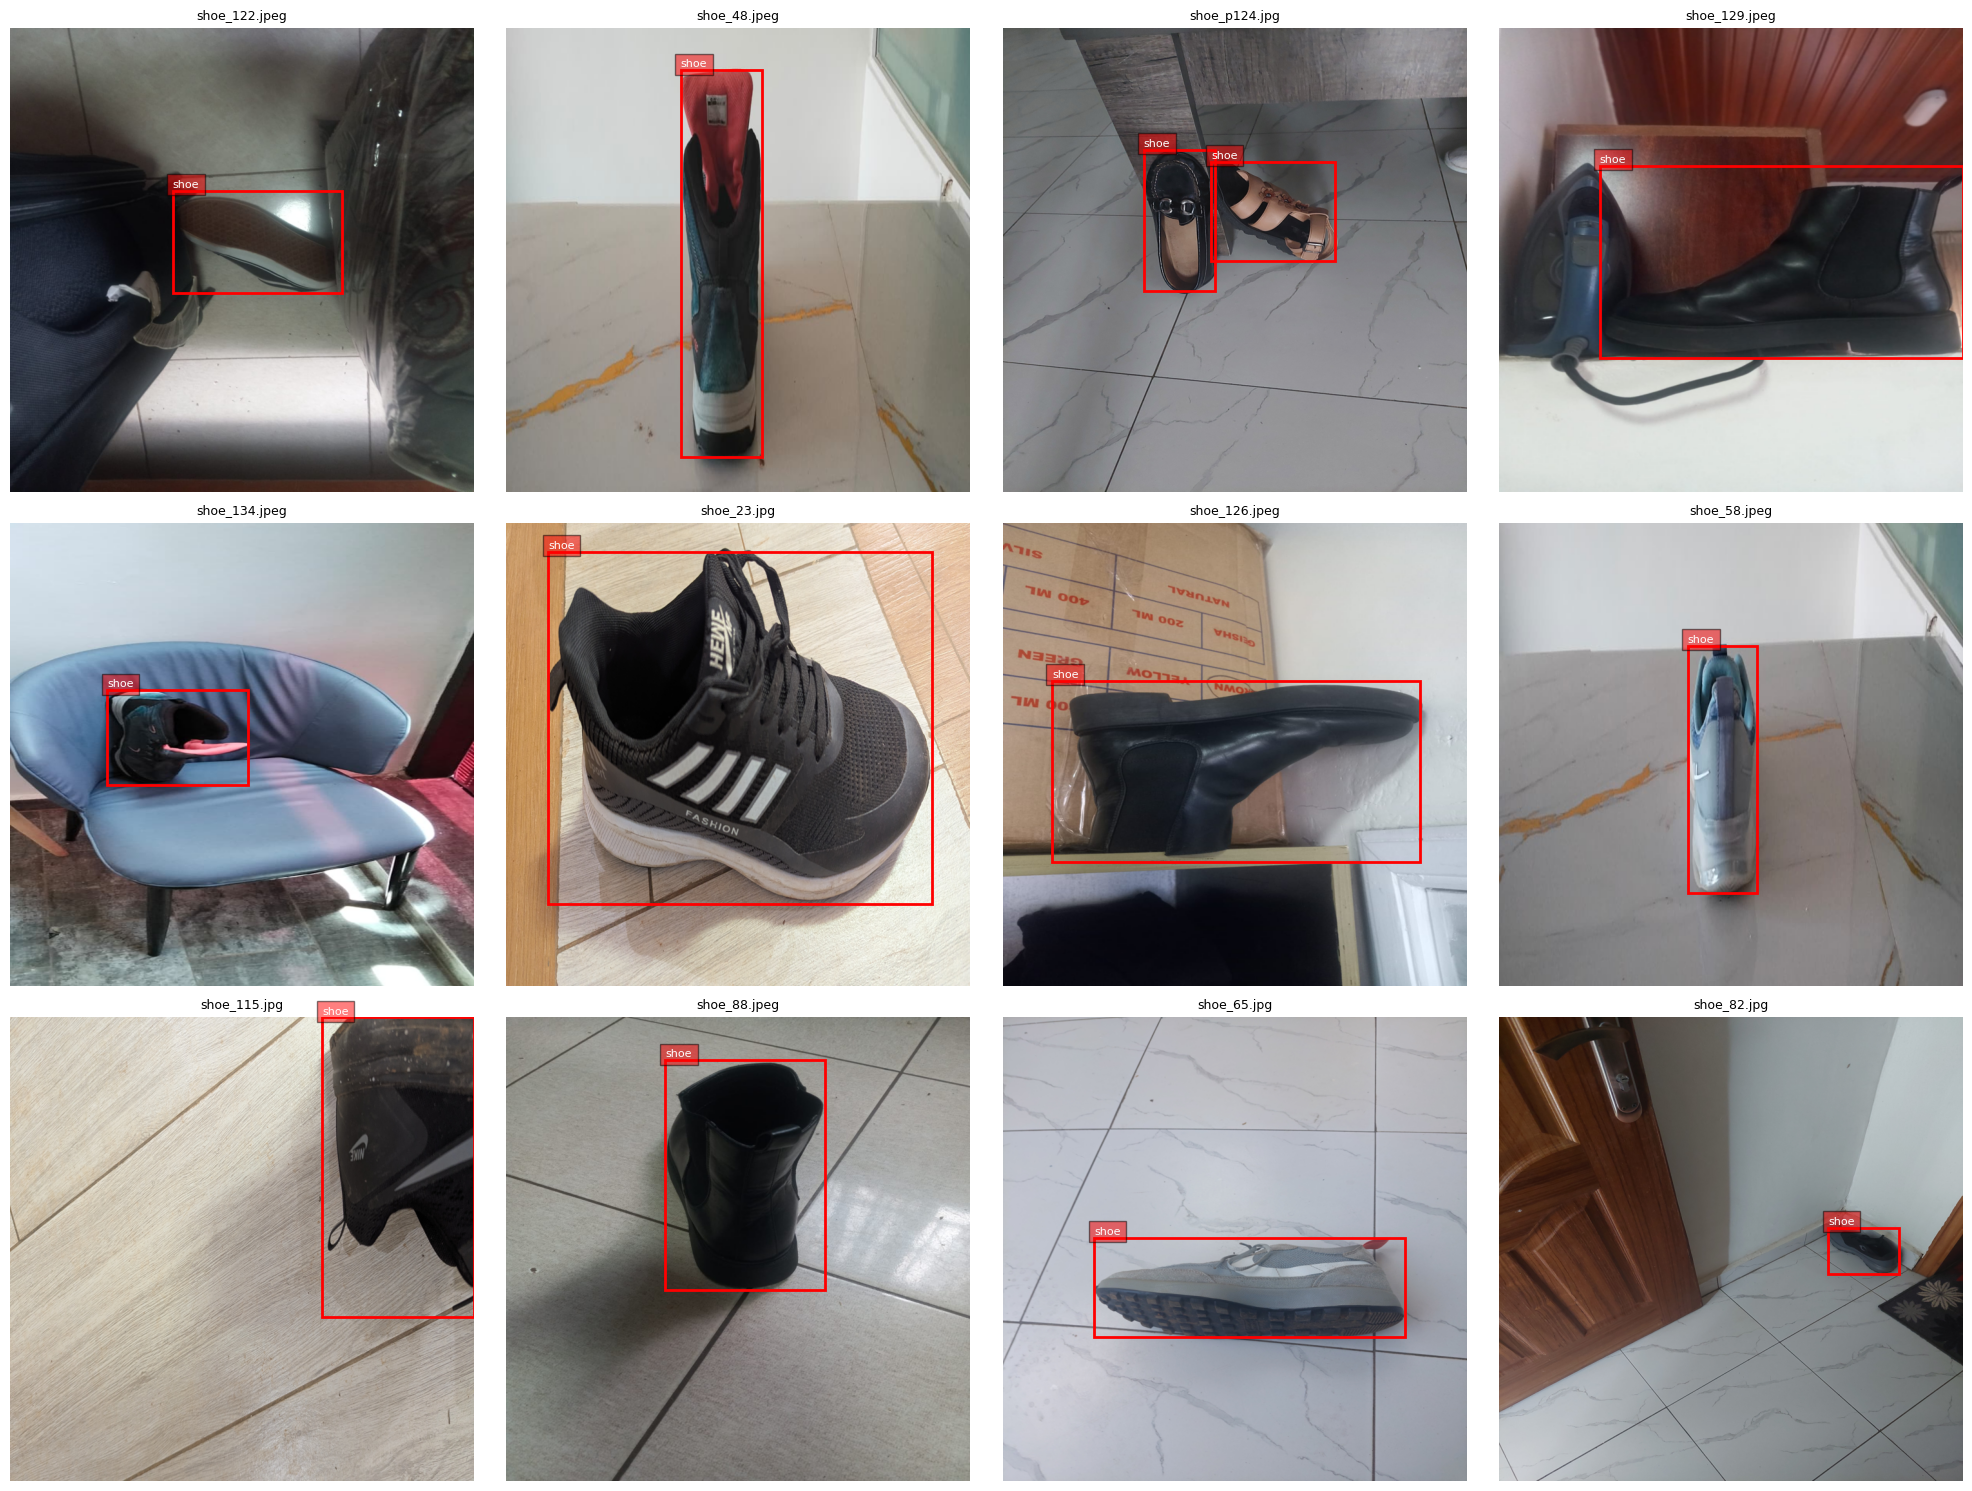

In [6]:
# Setup plot
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()
TARGET_SIZE = 720

for i, filename in enumerate(selected_images):
    img_path = Path('/kaggle/input/datasets/mitchmatheri/acv-hw4-shoe-dataset/data/raw') / filename
    
    if img_path.exists():
        # Open and immediately fix EXIF rotation
        img = Image.open(img_path)
        img = ImageOps.exif_transpose(img) 
        
        orig_w, orig_h = img.size
        
        # Resize and scale
        img_resized = img.resize((TARGET_SIZE, TARGET_SIZE))
        axes[i].imshow(img_resized)
        
        scale_x = TARGET_SIZE / orig_w
        scale_y = TARGET_SIZE / orig_h
    else:
        axes[i].text(0.5, 0.5, "File Not Found", ha='center', va='center', color='red')
        scale_x, scale_y = 1, 1

    # Filter and plot annotations
    image_anns = df[df['filename'] == filename]
    for _, row in image_anns.iterrows():
        new_xmin = row['xmin'] * scale_x
        new_ymin = row['ymin'] * scale_y
        new_w = row['width'] * scale_x
        new_h = row['height'] * scale_y

        rect = patches.Rectangle((new_xmin, new_ymin), new_w, new_h, 
                                 linewidth=2, edgecolor='r', facecolor='none')
        axes[i].add_patch(rect)
        axes[i].text(new_xmin, new_ymin - 5, row['class'], 
                     color='white', fontsize=8, bbox=dict(facecolor='red', alpha=0.5))

    axes[i].set_title(filename, fontsize=9)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Data Preparation 

In [7]:
YOLO_IMG_SIZE = 640  # Standard YOLO training size

class YOLODatasetPreparator:
    def __init__(self, csv_path, images_dir, output_dir, train_ratio=0.8, test_ratio=0.2):
        self.csv_path = csv_path
        self.images_dir = Path(images_dir)
        self.output_dir = Path(output_dir)
        self.train_ratio = train_ratio
        self.test_ratio = test_ratio
        
        assert abs(train_ratio + test_ratio - 1.0) < 1e-6

    # --------------------------------------------------
    # LOAD ANNOTATIONS
    # --------------------------------------------------
    def load_annotations(self):
        print("Loading annotations...")
        self.df = pd.read_csv(self.csv_path)

        self.classes = sorted(self.df['class'].unique().tolist())
        self.class_to_id = {cls: idx for idx, cls in enumerate(self.classes)}

        print("Classes:", self.class_to_id)

    # --------------------------------------------------
    # CREATE FOLDERS (train + test only)
    # --------------------------------------------------
    def create_directory_structure(self):
        for split in ['train','test']:
            (self.output_dir / split / 'images').mkdir(parents=True, exist_ok=True)
            (self.output_dir / split / 'labels').mkdir(parents=True, exist_ok=True)

    # --------------------------------------------------
    # SPLIT DATASET (80/20)
    # --------------------------------------------------
    def split_dataset(self):
        unique_images = self.df['filename'].unique()

        train, test = train_test_split(
            unique_images,
            test_size=self.test_ratio,
            random_state=42
        )

        self.splits = {
            'train': train.tolist(),
            'test': test.tolist()
        }

        print(f"Train images: {len(train)}")
        print(f"Test images: {len(test)}")

    # --------------------------------------------------
    # CONVERT TO YOLO FORMAT
    # --------------------------------------------------
    def convert_to_yolo_format(self, row, img_w, img_h, scale_x, scale_y):
        class_id = self.class_to_id[row['class']]

        xmin = row['xmin'] * scale_x
        ymin = row['ymin'] * scale_y
        width = row['width'] * scale_x
        height = row['height'] * scale_y

        x_center = (xmin + width/2) / img_w
        y_center = (ymin + height/2) / img_h
        norm_w = width / img_w
        norm_h = height / img_h

        return f"{class_id} {x_center:.6f} {y_center:.6f} {norm_w:.6f} {norm_h:.6f}"

    # --------------------------------------------------
    # PROCESS IMAGES + LABELS
    # --------------------------------------------------
    def process_images_and_labels(self):
        print("Processing images and labels...")

        for split_name, image_list in self.splits.items():
            print(f"Processing {split_name}...")

            for filename in image_list:
                img_path = self.images_dir / filename
                if not img_path.exists():
                    continue

                img = Image.open(img_path)
                img = ImageOps.exif_transpose(img)

                orig_w, orig_h = img.size

                img = img.resize((YOLO_IMG_SIZE, YOLO_IMG_SIZE))
                scale_x = YOLO_IMG_SIZE / orig_w
                scale_y = YOLO_IMG_SIZE / orig_h

                dest_img_path = self.output_dir / split_name / 'images' / filename
                img.save(dest_img_path, quality=95)

                label_filename = Path(filename).stem + ".txt"
                label_path = self.output_dir / split_name / 'labels' / label_filename

                image_annotations = self.df[self.df['filename'] == filename]

                with open(label_path, "w") as f:
                    for _, row in image_annotations.iterrows():
                        yolo_line = self.convert_to_yolo_format(
                            row,
                            YOLO_IMG_SIZE,
                            YOLO_IMG_SIZE,
                            scale_x,
                            scale_y
                        )
                        f.write(yolo_line + "\n")

    # --------------------------------------------------
    # CREATE YAML (train + test only)
    # --------------------------------------------------
    def create_dataset_yaml(self):
        yaml_content = {
            'path': str(self.output_dir.absolute()),
            'train': 'train/images',
            'val': 'test/images',   # YOLO expects val key → we reuse test as val
            'nc': len(self.classes),
            'names': self.classes
        }

        with open(self.output_dir / "dataset.yaml", "w") as f:
            yaml.dump(yaml_content, f, sort_keys=False)

    # --------------------------------------------------
    def run(self):
        print("Preparing YOLO dataset (80/20 SPLIT)")
        self.load_annotations()
        self.create_directory_structure()
        self.split_dataset()
        self.process_images_and_labels()
        self.create_dataset_yaml()
        print("Dataset ready!")

## Training 

In [8]:
from pathlib import Path
from ultralytics import YOLO
import torch
import yaml
from datetime import datetime


class YOLO11Trainer:
    """
    Robust YOLO trainer that works with dataset.yaml created by YOLODatasetPreparator
    """

    # --------------------------------------------------
    # INIT
    # --------------------------------------------------
    def __init__(self, dataset_dir, model_size='n', device=None):
        self.dataset_dir = Path(dataset_dir)
        self.device = device if device else ('cuda' if torch.cuda.is_available() else 'cpu')
        self.model_size = model_size

        print("\n📂 Using dataset directory:", self.dataset_dir)

        # 1️⃣ Locate existing YAML (created by DatasetPreparator)
        self.dataset_yaml = self.dataset_dir / "dataset.yaml"
        if not self.dataset_yaml.exists():
            raise FileNotFoundError(
                f"dataset.yaml not found in {self.dataset_dir}\n"
                "You MUST run YOLODatasetPreparator first."
            )

        # 2️⃣ Load YAML
        with open(self.dataset_yaml, "r") as f:
            self.dataset_config = yaml.safe_load(f)

        self.class_names = self.dataset_config["names"]
        self.num_classes = self.dataset_config["nc"]

        # 3️⃣ Validate dataset structure BEFORE training
        self._validate_dataset_structure()

        print("✓ Dataset validated successfully")
        print("Classes:", self.class_names)
        print("Device:", self.device)

    # --------------------------------------------------
    # VALIDATE DATASET STRUCTURE
    # --------------------------------------------------
    def _validate_dataset_structure(self):
        """
        Ensures the dataset folders expected by YOLO actually exist.
        Handles 'test' vs 'val' automatically.
        """

        train_dir = self.dataset_dir / "train" / "images"

        # DatasetPreparator uses TEST as validation
        test_dir = self.dataset_dir / "test" / "images"
        val_dir = self.dataset_dir / "val" / "images"

        if not train_dir.exists():
            raise RuntimeError(f"Missing training images at {train_dir}")

        # Auto-handle val/test naming
        if test_dir.exists() and not val_dir.exists():
            print("⚠️ No 'val' folder found — using 'test' as validation set")
            self.dataset_config["val"] = "test/images"
            with open(self.dataset_yaml, "w") as f:
                yaml.dump(self.dataset_config, f, sort_keys=False)

        print("✓ Dataset structure OK")

    # --------------------------------------------------
    # LOAD MODEL
    # --------------------------------------------------
    def load_pretrained_model(self):
        model_name = f"yolo11{self.model_size}.pt"
        print("\n🚀 Loading pretrained", model_name)
        self.model = YOLO(model_name)

    # --------------------------------------------------
    # HYPERPARAMETERS
    # --------------------------------------------------
    def configure_hyperparameters(self, **kwargs):
        self.hyperparameters = {
            "epochs": 50,
            "batch": 16,
            "imgsz": 640,
            "optimizer": "AdamW",
            "lr0": 0.001,
            "device": self.device,
            "workers": 8,
            "project": "runs/train",
            "name": f"yolo11{self.model_size}_custom",
            "exist_ok": True,
            "verbose": True,
            # augmentation
            "degrees": 10,
            "translate": 0.1,
            "scale": 0.5,
            "fliplr": 0.5,
            "mosaic": 1.0,
        }

        self.hyperparameters.update(kwargs)

        print("\n⚙️ Training hyperparameters:")
        for k, v in self.hyperparameters.items():
            print(f"{k:15s}: {v}")

    # --------------------------------------------------
    # SAVE CONFIG
    # --------------------------------------------------
    def save_config(self):
        config_dir = Path(self.hyperparameters["project"]) / self.hyperparameters["name"]
        config_dir.mkdir(parents=True, exist_ok=True)

        config = {
            "dataset_dir": str(self.dataset_dir),
            "dataset_yaml": str(self.dataset_yaml),
            "classes": self.class_names,
            "device": str(self.device),
            "hyperparameters": self.hyperparameters,
            "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        }

        with open(config_dir / "training_config.yaml", "w") as f:
            yaml.dump(config, f, sort_keys=False)

    # --------------------------------------------------
    # TRAIN
    # --------------------------------------------------
    def train(self):
        print("\n🔥 STARTING YOLO TRAINING")

        results = self.model.train(
            data=str(self.dataset_yaml),
            **self.hyperparameters
        )

        print("\n✅ TRAINING FINISHED")
        return results

    # --------------------------------------------------
    # PIPELINE
    # --------------------------------------------------
    def run(self, **hyperparameter_overrides):
        print("\n" + "="*70)
        print("YOLO11 TRAINING PIPELINE")
        print("="*70)

        self.load_pretrained_model()
        self.configure_hyperparameters(**hyperparameter_overrides)
        self.save_config()
        return self.train()

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [11]:
# ==========================================================
# MASTER PIPELINE — DATASET + TRAINING FOR MULTIPLE SEEDS
# ==========================================================

def train_with_multiple_random_splits(
    dataset_csv_path="/kaggle/input/datasets/martinkoome/shoe-annotation/shoe_annotations.csv",
    images_dir="/kaggle/input/datasets/mitchmatheri/acv-hw4-shoe-dataset/data/raw",
    seeds=[42, 123, 2026],
    train_ratio=0.8,
    test_ratio=0.2,
    model_size='n',
    epochs=50,
    batch=16,
    imgsz=640,
    lr0=0.001
):
    import pandas as pd
    results_summary = []

    for seed in seeds:
        print("\n" + "="*80)
        print(f"🚀 FULL PIPELINE FOR SEED = {seed}")
        print("="*80)

        # ==================================================
        # STEP 1 — PREPARE YOLO DATASET (IMAGES + LABELS)
        # ==================================================
        dataset_root = f"data/yolo_dataset_seed_{seed}"

        preparator = YOLODatasetPreparator(
            csv_path=dataset_csv_path,
            images_dir=images_dir,
            output_dir=dataset_root,
            train_ratio=train_ratio,
            test_ratio=test_ratio
        )

        # 🔴 override random seed in splitter
        from sklearn.model_selection import train_test_split
        def split_with_seed(self):
            unique_images = self.df['filename'].unique()
            train, test = train_test_split(
                unique_images,
                test_size=self.test_ratio,
                random_state=seed
            )
            self.splits = {'train': train.tolist(), 'test': test.tolist()}

        preparator.split_dataset = split_with_seed.__get__(preparator)

        # 🔥 THIS BUILDS IMAGES + LABELS + YAML
        preparator.run()

        class_names = preparator.classes

        # ==================================================
        # STEP 2 — TRAIN YOLO ON THIS DATASET
        # ==================================================
        trainer = YOLO11Trainer(
            dataset_dir=dataset_root,
        )

        results = trainer.run(
            epochs=epochs,
            batch=batch,
            imgsz=imgsz,
            lr0=lr0,
            name=f"yolo11_seed_{seed}"
        )

        results_summary.append({
            "seed": seed,
            "results": results
        })

    return results_summary

In [12]:
results = train_with_multiple_random_splits()


🚀 FULL PIPELINE FOR SEED = 42
Preparing YOLO dataset (80/20 SPLIT)
Loading annotations...
Classes: {'shoe': 0}
Processing images and labels...
Processing train...
Processing test...
Dataset ready!

📂 Using dataset directory: data/yolo_dataset_seed_42
⚠️ No 'val' folder found — using 'test' as validation set
✓ Dataset structure OK
✓ Dataset validated successfully
Classes: ['shoe']
Device: cuda

YOLO11 TRAINING PIPELINE

🚀 Loading pretrained yolo11n.pt

⚙️ Training hyperparameters:
epochs         : 50
batch          : 16
imgsz          : 640
optimizer      : AdamW
lr0            : 0.001
device         : cuda
workers        : 8
project        : runs/train
name           : yolo11_seed_42
exist_ok       : True
verbose        : True
degrees        : 10
translate      : 0.1
scale          : 0.5
fliplr         : 0.5
mosaic         : 1.0

🔥 STARTING YOLO TRAINING
Ultralytics 8.4.36 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, ang

In [13]:
! ls /kaggle/working/data

yolo_dataset_seed_123  yolo_dataset_seed_2026  yolo_dataset_seed_42


In [17]:
!cat /kaggle/working/data/yolo_dataset_seed_42/dataset.yaml

path: /kaggle/working/data/yolo_dataset_seed_42
train: train/images
val: test/images
nc: 1
names:
- shoe


In [19]:
! ls /kaggle/working/data/yolo_dataset_seed_42

dataset.yaml  test  train


In [15]:
# ==========================================================
# AGGREGATE MULTI-SEED TRAINING RESULTS (MEAN ± STD)
# ==========================================================
import pandas as pd
import numpy as np
from pathlib import Path


def load_final_metrics(results_csv):
    """
    Load YOLO results.csv and return metrics from LAST epoch
    """
    df = pd.read_csv(results_csv)
    last_row = df.iloc[-1]

    metrics = {
        "precision": last_row["metrics/precision(B)"],
        "recall": last_row["metrics/recall(B)"],
        "mAP50": last_row["metrics/mAP50(B)"],
        "mAP50-95": last_row["metrics/mAP50-95(B)"],
        "val_box_loss": last_row["val/box_loss"],
        "val_cls_loss": last_row["val/cls_loss"],
        "val_dfl_loss": last_row["val/dfl_loss"],
    }

    return metrics


def aggregate_seed_runs(seeds=[42, 123, 2026], runs_dir="runs/train"):
    """
    Aggregate YOLO runs trained with different random seeds
    """

    print("\n" + "="*70)
    print("AGGREGATING MULTIPLE RANDOM SPLIT RESULTS")
    print("="*70)

    all_results = []

    for seed in seeds:
        csv_path = f"/kaggle/working/runs/detect/runs/train/yolo11_seed_{seed}/results.csv"

        # if not csv_path.exists():
        #     print(f"❌ Missing results for seed {seed}")
        #     continue

        metrics = load_final_metrics(csv_path)
        metrics["seed"] = seed
        all_results.append(metrics)

        print(f"Loaded results for seed {seed}")

    df = pd.DataFrame(all_results).set_index("seed")

    # ------------------------------------------------------
    # COMPUTE MEAN AND STD
    # ------------------------------------------------------
    mean_vals = df.mean()
    std_vals = df.std()

    summary = pd.DataFrame({
        "Mean": mean_vals,
        "Std": std_vals
    })

    # Format Mean ± Std column (nice for report)
    summary["Mean ± Std"] = summary.apply(
        lambda row: f"{row['Mean']:.4f} ± {row['Std']:.4f}", axis=1
    )

    print("\nFINAL ROBUSTNESS RESULTS")
    print(summary[["Mean ± Std"]])

    # ------------------------------------------------------
    # SAVE TABLE FOR REPORT
    # ------------------------------------------------------
    save_path = Path("runs") / "multi_seed_summary.csv"
    summary.to_csv(save_path)

    print(f"\nSaved summary → {save_path}")

    return df, summary

In [16]:
df, summary = aggregate_seed_runs()


AGGREGATING MULTIPLE RANDOM SPLIT RESULTS
Loaded results for seed 42
Loaded results for seed 123
Loaded results for seed 2026

FINAL ROBUSTNESS RESULTS
                   Mean ± Std
precision     0.9466 ± 0.0234
recall        0.8498 ± 0.1027
mAP50         0.8881 ± 0.0988
mAP50-95      0.6803 ± 0.0985
val_box_loss  0.9857 ± 0.1624
val_cls_loss  0.6916 ± 0.1891
val_dfl_loss  1.3119 ± 0.0620

Saved summary → runs/multi_seed_summary.csv


## Evaluation 

YOLO11 EVALUATION PIPELINE INITIALIZED
Dataset path: /kaggle/working/data/yolo_dataset_seed_42
Output directory: evaluation_output
✓ Added model: Model_Seed_123 (seed=123)
⚠️  Warning: Model not found: /kaggle/working/runs/detect/runs/train/yolo11_seed_456/weights/best.pt
⚠️  Warning: Model not found: /kaggle/working/runs/detect/runs/train/yolo11_seed_789/weights/best.pt

RUNNING COMPLETE EVALUATION PIPELINE

EVALUATING ALL 1 MODELS

EVALUATING: Model_Seed_123
Ultralytics 8.4.36 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1744.2±526.3 MB/s, size: 92.7 KB)
val: Scanning /kaggle/working/data/yolo_dataset_seed_42/test/labels.cache... 30 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30 4.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.4it/s 0.8s1.5s
    

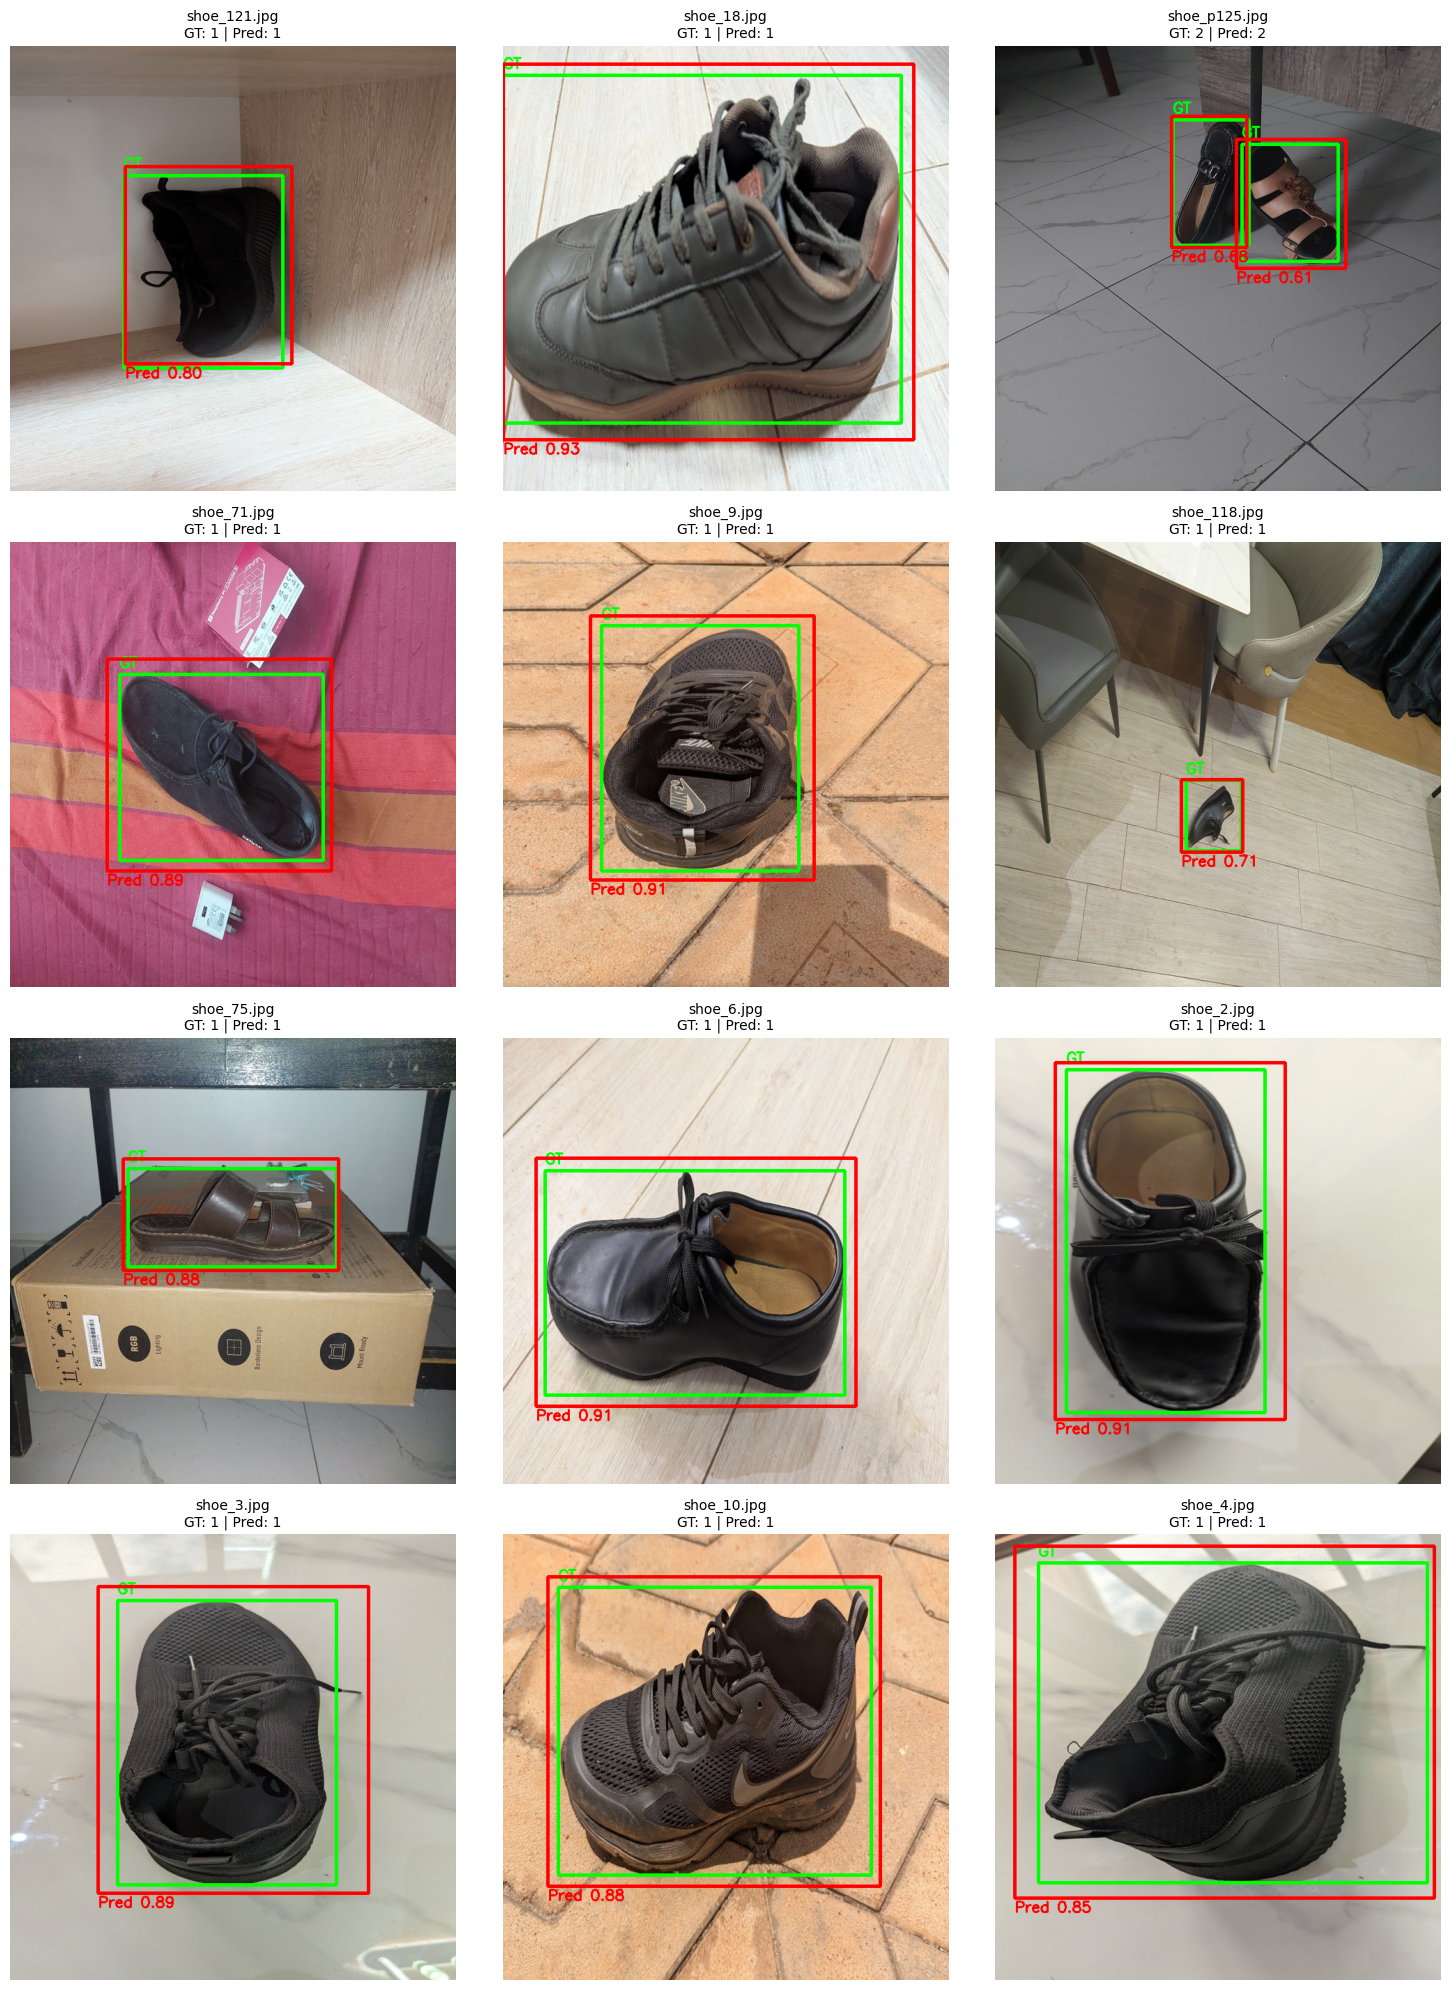


CREATING PERFORMANCE CHARTS
✓ Saved performance charts to: evaluation_output/performance_charts.png


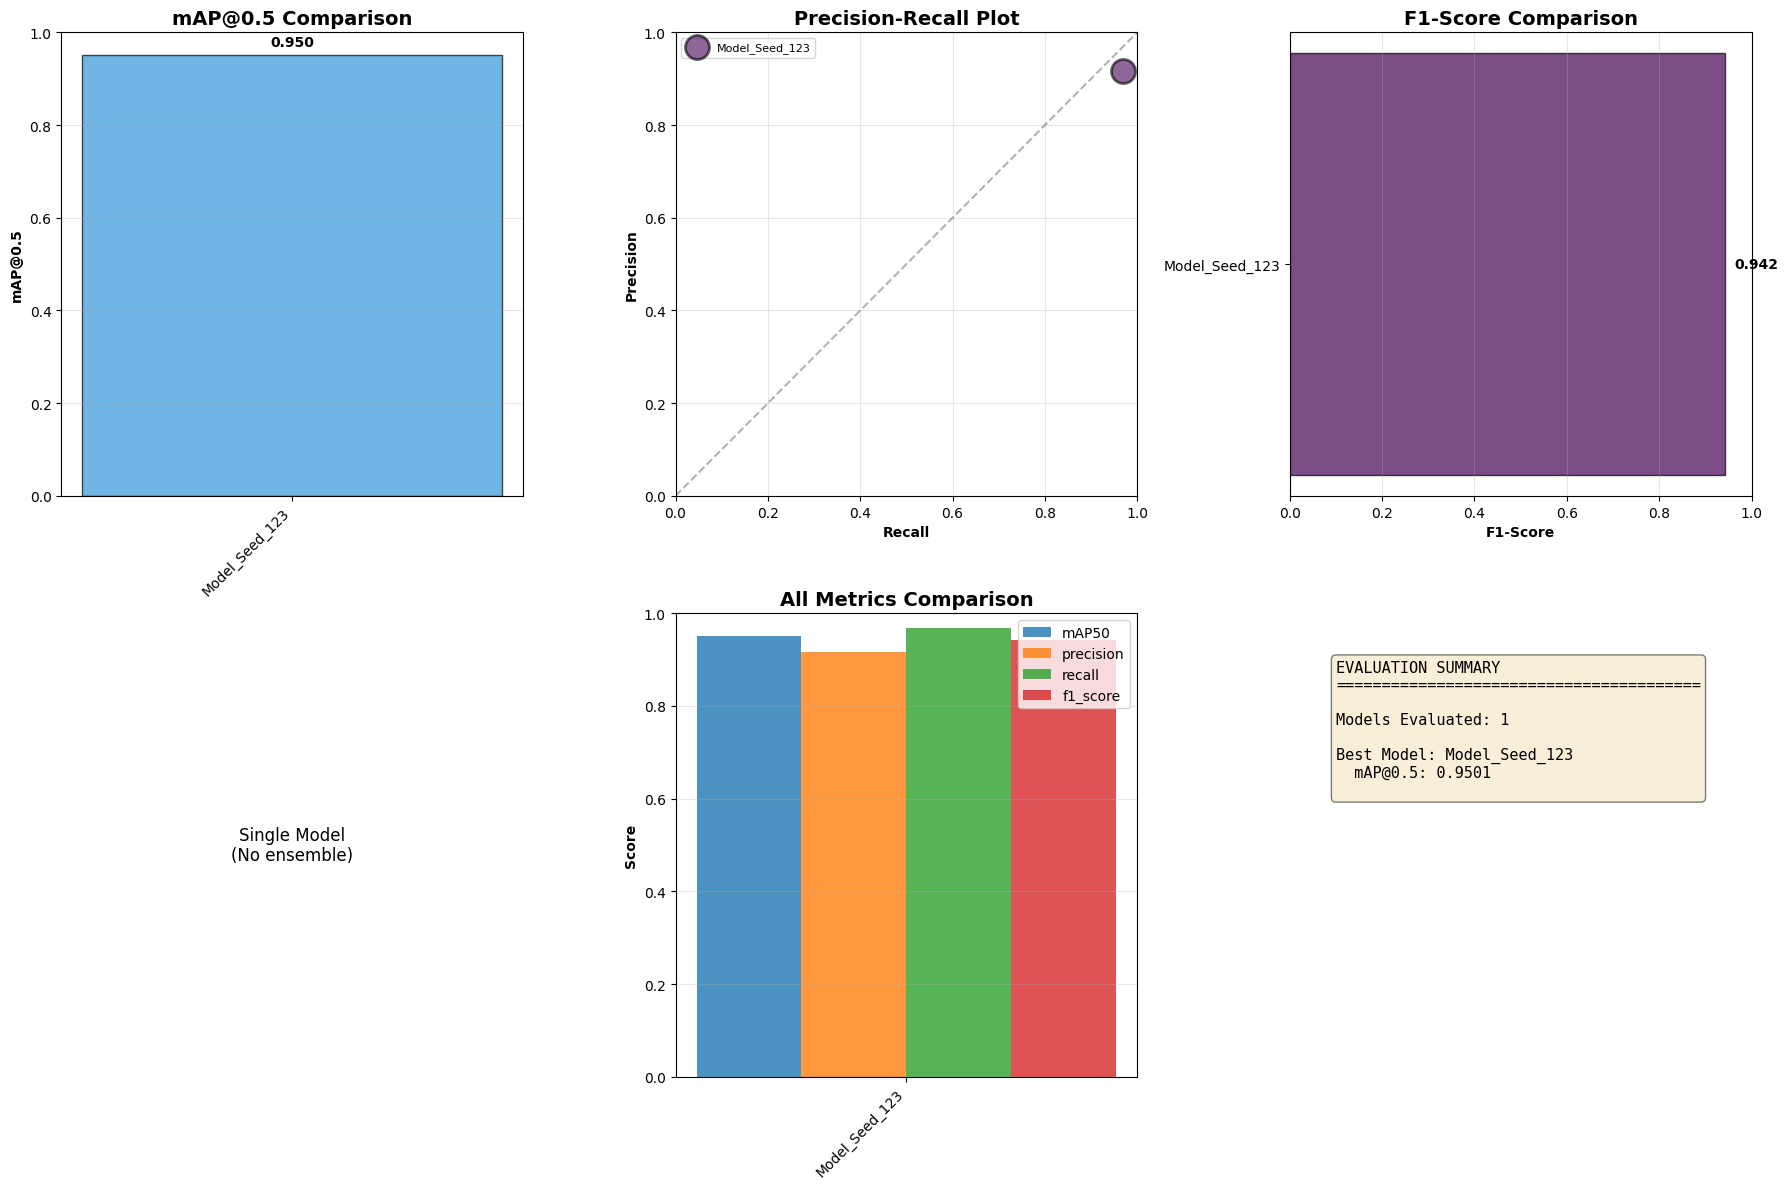


GENERATING EVALUATION REPORT
✓ Saved report to: evaluation_output/evaluation_report.txt

EVALUATION COMPLETE!
Results saved to: /kaggle/working/evaluation_output

Generated files:
  - ensemble_results.csv
  - predictions_grid.png
  - gt_vs_predictions/ (individual comparisons)
  - performance_charts.png
  - evaluation_report.txt

✓ Evaluation complete!


In [21]:
"""
COMPLETE YOLO11 EVALUATION PIPELINE - FIXED VERSION
Evaluates individual models and ensemble across multiple random seeds
Includes ground truth vs prediction visualization
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from ultralytics import YOLO
import json
from datetime import datetime

class CompleteYOLO11Evaluator:
    """
    Complete evaluation pipeline for YOLO11 models
    Supports single model and multi-seed ensemble evaluation
    """
    
    def __init__(self, dataset_path, output_dir='evaluation_output'):
        """
        Args:
            dataset_path: Path to dataset root (contains train/val/test folders)
            output_dir: Directory to save evaluation results
        """
        self.dataset_path = Path(dataset_path)
        self.output_dir = Path(output_dir)
        self.output_dir.mkdir(exist_ok=True, parents=True)
        
        # Storage for results
        self.models = []
        self.individual_results = []
        self.ensemble_results = {}
        
        print("="*70)
        print("YOLO11 EVALUATION PIPELINE INITIALIZED")
        print("="*70)
        print(f"Dataset path: {self.dataset_path}")
        print(f"Output directory: {self.output_dir}")
    
    def add_model(self, model_path, seed=None, name=None):
        """
        Add a trained model for evaluation
        
        Args:
            model_path: Path to trained model weights (.pt file)
            seed: Random seed used for training (optional)
            name: Model name (optional)
        """
        model_path = Path(model_path)
        
        if not model_path.exists():
            print(f"⚠️  Warning: Model not found: {model_path}")
            return
        
        model = YOLO(str(model_path))
        
        model_info = {
            'model': model,
            'path': str(model_path),
            'seed': seed,
            'name': name or f"Model_{len(self.models)+1}"
        }
        
        self.models.append(model_info)
        print(f"✓ Added model: {model_info['name']} (seed={seed})")
    
    def evaluate_single_model(self, model_info, split='val'):
        """
        Evaluate a single model on validation or test set
        
        Args:
            model_info: Dictionary with model information
            split: Dataset split to evaluate on ('val' or 'test')
        """
        print(f"\n{'='*70}")
        print(f"EVALUATING: {model_info['name']}")
        print(f"{'='*70}")
        
        model = model_info['model']
        
        # Run validation
        results = model.val(
            data=str(self.dataset_path / 'dataset.yaml') if (self.dataset_path / 'dataset.yaml').exists() else None,
            # split=split,
            save_json=False,
            verbose=False
        )
        
        # Extract metrics
        metrics = {
            'model_name': model_info['name'],
            'seed': model_info['seed'],
            'split': split,
            'mAP50': float(results.box.map50) if hasattr(results.box, 'map50') else 0.0,
            'mAP50-95': float(results.box.map) if hasattr(results.box, 'map') else 0.0,
            'precision': float(results.box.mp) if hasattr(results.box, 'mp') else 0.0,
            'recall': float(results.box.mr) if hasattr(results.box, 'mr') else 0.0,
        }
        
        # Calculate F1 score
        if metrics['precision'] + metrics['recall'] > 0:
            metrics['f1_score'] = 2 * (metrics['precision'] * metrics['recall']) / (metrics['precision'] + metrics['recall'])
        else:
            metrics['f1_score'] = 0.0
        
        print(f"\nMetrics on {split} set:")
        print(f"  mAP@0.5      : {metrics['mAP50']:.4f}")
        print(f"  mAP@0.5:0.95 : {metrics['mAP50-95']:.4f}")
        print(f"  Precision    : {metrics['precision']:.4f}")
        print(f"  Recall       : {metrics['recall']:.4f}")
        print(f"  F1-Score     : {metrics['f1_score']:.4f}")
        
        return metrics
    
    def evaluate_all_models(self, split='val'):
        """Evaluate all added models"""
        print(f"\n{'='*70}")
        print(f"EVALUATING ALL {len(self.models)} MODELS")
        print(f"{'='*70}")
        
        self.individual_results = []
        
        for model_info in self.models:
            metrics = self.evaluate_single_model(model_info, split=split)
            self.individual_results.append(metrics)
        
        # Create results DataFrame
        self.results_df = pd.DataFrame(self.individual_results)
        
        print(f"\n{'='*70}")
        print("ALL MODELS EVALUATED")
        print(f"{'='*70}")
        print(self.results_df.to_string(index=False))
        
        return self.results_df
    
    def compute_ensemble_metrics(self):
        """Compute mean and std across all models (ensemble metrics)"""
        if len(self.individual_results) == 0:
            print("⚠️  No results to aggregate. Run evaluate_all_models() first.")
            return
        
        print(f"\n{'='*70}")
        print("COMPUTING ENSEMBLE METRICS (Mean ± Std)")
        print(f"{'='*70}")
        
        df = self.results_df
        
        metrics = ['mAP50', 'mAP50-95', 'precision', 'recall', 'f1_score']
        
        ensemble_stats = {}
        for metric in metrics:
            mean_val = df[metric].mean()
            std_val = df[metric].std()
            ensemble_stats[metric] = {
                'mean': mean_val,
                'std': std_val,
                'formatted': f"{mean_val:.4f} ± {std_val:.4f}"
            }
        
        # Print results
        print("\nEnsemble Results:")
        for metric, stats in ensemble_stats.items():
            print(f"  {metric:15s}: {stats['formatted']}")
        
        self.ensemble_results = ensemble_stats
        
        # Save to CSV
        ensemble_df = pd.DataFrame({
            'Metric': list(ensemble_stats.keys()),
            'Mean': [v['mean'] for v in ensemble_stats.values()],
            'Std': [v['std'] for v in ensemble_stats.values()],
            'Mean ± Std': [v['formatted'] for v in ensemble_stats.values()]
        })
        
        csv_path = self.output_dir / 'ensemble_results.csv'
        ensemble_df.to_csv(csv_path, index=False)
        print(f"\n✓ Saved ensemble results to: {csv_path}")
        
        return ensemble_stats
    
    def visualize_predictions_vs_ground_truth(self, model_index=0, num_samples=12, split='test'):
        """
        Visualize ground truth vs predictions side-by-side
        
        Args:
            model_index: Index of model to use for predictions (default: 0 = first model)
            num_samples: Number of sample images to visualize
            split: Dataset split ('val' or 'test')
        """
        print(f"\n{'='*70}")
        print(f"VISUALIZING PREDICTIONS vs GROUND TRUTH")
        print(f"{'='*70}")
        
        if len(self.models) == 0:
            print("⚠️  No models loaded. Add models first.")
            return
        
        model_info = self.models[model_index]
        model = model_info['model']
        
        # Get images and labels
        img_dir = self.dataset_path / split / 'images'
        label_dir = self.dataset_path / split / 'labels'
        
        if not img_dir.exists():
            print(f"⚠️  Image directory not found: {img_dir}")
            return
        
        # Get sample images
        image_files = list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png'))
        
        if len(image_files) == 0:
            print(f"⚠️  No images found in {img_dir}")
            return
        
        sample_images = np.random.choice(image_files, min(num_samples, len(image_files)), replace=False)
        
        # Create output directory
        save_dir = self.output_dir / 'gt_vs_predictions'
        save_dir.mkdir(exist_ok=True)
        
        # Setup plot
        rows = int(np.ceil(np.sqrt(num_samples)))
        cols = int(np.ceil(num_samples / rows))
        
        fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
        axes = axes.flatten() if num_samples > 1 else [axes]
        
        for idx, img_path in enumerate(sample_images):
            # Read image
            image = cv2.imread(str(img_path))
            if image is None:
                continue
            
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            h, w, _ = image.shape
            
            # Create copy for drawing
            img_display = image_rgb.copy()
            
            # Draw ground truth boxes (GREEN)
            label_path = label_dir / f"{img_path.stem}.txt"
            num_gt = 0
            if label_path.exists():
                with open(label_path, 'r') as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) >= 5:
                            cls, x_center, y_center, box_w, box_h = map(float, parts[:5])
                            
                            # Convert YOLO format to pixel coordinates
                            x1 = int((x_center - box_w/2) * w)
                            y1 = int((y_center - box_h/2) * h)
                            x2 = int((x_center + box_w/2) * w)
                            y2 = int((y_center + box_h/2) * h)
                            
                            # Draw rectangle
                            cv2.rectangle(img_display, (x1, y1), (x2, y2), (0, 255, 0), 3)
                            cv2.putText(img_display, 'GT', (x1, y1-10),
                                      cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
                            num_gt += 1
            
            # Draw predictions (RED)
            results = model.predict(str(img_path), conf=0.25, verbose=False)
            num_pred = 0
            if results[0].boxes is not None and len(results[0].boxes) > 0:
                boxes = results[0].boxes.xyxy.cpu().numpy()
                confs = results[0].boxes.conf.cpu().numpy()
                
                for box, conf in zip(boxes, confs):
                    x1, y1, x2, y2 = map(int, box)
                    
                    # Draw rectangle
                    cv2.rectangle(img_display, (x1, y1), (x2, y2), (255, 0, 0), 3)
                    cv2.putText(img_display, f'Pred {conf:.2f}', (x1, y2+20),
                              cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
                    num_pred += 1
            
            # Display
            axes[idx].imshow(img_display)
            axes[idx].set_title(f'{img_path.name}\nGT: {num_gt} | Pred: {num_pred}', fontsize=10)
            axes[idx].axis('off')
            
            # Save individual comparison
            save_path = save_dir / f"{img_path.stem}_comparison.jpg"
            cv2.imwrite(str(save_path), cv2.cvtColor(img_display, cv2.COLOR_RGB2BGR))
        
        # Hide extra subplots
        for idx in range(len(sample_images), len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        
        # Save grid
        grid_path = self.output_dir / 'predictions_grid.png'
        plt.savefig(grid_path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved predictions grid to: {grid_path}")
        print(f"✓ Saved individual comparisons to: {save_dir}/")
        
        plt.show()
        plt.close()
    
    def create_performance_charts(self):
        """Create comprehensive performance visualization"""
        if len(self.individual_results) == 0:
            print("⚠️  No results to visualize. Run evaluate_all_models() first.")
            return
        
        print(f"\n{'='*70}")
        print("CREATING PERFORMANCE CHARTS")
        print(f"{'='*70}")
        
        df = self.results_df
        
        # Create figure
        fig = plt.figure(figsize=(18, 12))
        
        # 1. Model Comparison - mAP@0.5
        ax1 = plt.subplot(2, 3, 1)
        x = range(len(df))
        ax1.bar(x, df['mAP50'], color='#3498db', alpha=0.7, edgecolor='black')
        ax1.set_xticks(x)
        ax1.set_xticklabels(df['model_name'], rotation=45, ha='right')
        ax1.set_ylabel('mAP@0.5', fontweight='bold')
        ax1.set_title('mAP@0.5 Comparison', fontweight='bold', fontsize=14)
        ax1.set_ylim([0, 1])
        ax1.grid(axis='y', alpha=0.3)
        
        # Add value labels
        for i, v in enumerate(df['mAP50']):
            ax1.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
        
        # 2. Precision vs Recall
        ax2 = plt.subplot(2, 3, 2)
        colors = plt.cm.viridis(np.linspace(0, 1, len(df)))
        for i, (_, row) in enumerate(df.iterrows()):
            ax2.scatter(row['recall'], row['precision'], s=300, c=[colors[i]], 
                       alpha=0.6, edgecolors='black', linewidths=2, label=row['model_name'])
        
        ax2.plot([0, 1], [0, 1], 'k--', alpha=0.3)
        ax2.set_xlabel('Recall', fontweight='bold')
        ax2.set_ylabel('Precision', fontweight='bold')
        ax2.set_title('Precision-Recall Plot', fontweight='bold', fontsize=14)
        ax2.set_xlim([0, 1])
        ax2.set_ylim([0, 1])
        ax2.legend(fontsize=8)
        ax2.grid(alpha=0.3)
        
        # 3. F1-Score Comparison
        ax3 = plt.subplot(2, 3, 3)
        ax3.barh(df['model_name'], df['f1_score'], color=colors, alpha=0.7, edgecolor='black')
        ax3.set_xlabel('F1-Score', fontweight='bold')
        ax3.set_title('F1-Score Comparison', fontweight='bold', fontsize=14)
        ax3.set_xlim([0, 1])
        ax3.grid(axis='x', alpha=0.3)
        
        # Add value labels
        for i, v in enumerate(df['f1_score']):
            ax3.text(v + 0.02, i, f'{v:.3f}', va='center', fontweight='bold')
        
        # 4. Ensemble Statistics (if multiple models)
        ax4 = plt.subplot(2, 3, 4)
        if len(df) > 1:
            metrics = ['mAP50', 'mAP50-95', 'precision', 'recall', 'f1_score']
            means = [df[m].mean() for m in metrics]
            stds = [df[m].std() for m in metrics]
            
            x_pos = range(len(metrics))
            ax4.bar(x_pos, means, yerr=stds, capsize=5, alpha=0.7, 
                   color='#2ecc71', edgecolor='black', error_kw={'linewidth': 2})
            ax4.set_xticks(x_pos)
            ax4.set_xticklabels(metrics, rotation=45, ha='right')
            ax4.set_ylabel('Score', fontweight='bold')
            ax4.set_title('Ensemble Metrics (Mean ± Std)', fontweight='bold', fontsize=14)
            ax4.set_ylim([0, 1])
            ax4.grid(axis='y', alpha=0.3)
        else:
            ax4.text(0.5, 0.5, 'Single Model\n(No ensemble)', 
                    ha='center', va='center', fontsize=12)
            ax4.axis('off')
        
        # 5. All Metrics Comparison
        ax5 = plt.subplot(2, 3, 5)
        metrics_to_plot = ['mAP50', 'precision', 'recall', 'f1_score']
        width = 0.2
        x = np.arange(len(df))
        
        for i, metric in enumerate(metrics_to_plot):
            offset = width * (i - len(metrics_to_plot)/2 + 0.5)
            ax5.bar(x + offset, df[metric], width, label=metric, alpha=0.8)
        
        ax5.set_xticks(x)
        ax5.set_xticklabels(df['model_name'], rotation=45, ha='right')
        ax5.set_ylabel('Score', fontweight='bold')
        ax5.set_title('All Metrics Comparison', fontweight='bold', fontsize=14)
        ax5.legend()
        ax5.set_ylim([0, 1])
        ax5.grid(axis='y', alpha=0.3)
        
        # 6. Summary Statistics
        ax6 = plt.subplot(2, 3, 6)
        ax6.axis('off')
        
        summary_text = "EVALUATION SUMMARY\n" + "="*40 + "\n\n"
        summary_text += f"Models Evaluated: {len(df)}\n\n"
        
        if len(df) > 1:
            summary_text += "Ensemble Results (Mean ± Std):\n"
            summary_text += f"  mAP@0.5    : {df['mAP50'].mean():.4f} ± {df['mAP50'].std():.4f}\n"
            summary_text += f"  Precision  : {df['precision'].mean():.4f} ± {df['precision'].std():.4f}\n"
            summary_text += f"  Recall     : {df['recall'].mean():.4f} ± {df['recall'].std():.4f}\n"
            summary_text += f"  F1-Score   : {df['f1_score'].mean():.4f} ± {df['f1_score'].std():.4f}\n\n"
        
        best_model_idx = df['mAP50'].idxmax()
        summary_text += f"Best Model: {df.loc[best_model_idx, 'model_name']}\n"
        summary_text += f"  mAP@0.5: {df.loc[best_model_idx, 'mAP50']:.4f}\n"
        
        ax6.text(0.1, 0.9, summary_text, transform=ax6.transAxes,
                fontsize=11, verticalalignment='top', family='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        plt.tight_layout()
        
        # Save
        chart_path = self.output_dir / 'performance_charts.png'
        plt.savefig(chart_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved performance charts to: {chart_path}")
        
        plt.show()
        plt.close()
    
    def generate_report(self):
        """Generate comprehensive evaluation report"""
        print(f"\n{'='*70}")
        print("GENERATING EVALUATION REPORT")
        print(f"{'='*70}")
        
        report_path = self.output_dir / 'evaluation_report.txt'
        
        with open(report_path, 'w') as f:
            f.write("="*70 + "\n")
            f.write("YOLO11 SHOE DETECTION - EVALUATION REPORT\n")
            f.write("="*70 + "\n\n")
            
            f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
            f.write(f"Dataset: {self.dataset_path}\n")
            f.write(f"Models Evaluated: {len(self.models)}\n\n")
            
            # Individual model results
            f.write("="*70 + "\n")
            f.write("INDIVIDUAL MODEL RESULTS\n")
            f.write("="*70 + "\n\n")
            f.write(self.results_df.to_string(index=False) + "\n\n")
            
            # Ensemble results
            if len(self.models) > 1 and self.ensemble_results:
                f.write("="*70 + "\n")
                f.write("ENSEMBLE RESULTS (Mean ± Std)\n")
                f.write("="*70 + "\n\n")
                for metric, stats in self.ensemble_results.items():
                    f.write(f"{metric:15s}: {stats['formatted']}\n")
                f.write("\n")
            
            # Best model
            best_idx = self.results_df['mAP50'].idxmax()
            f.write("="*70 + "\n")
            f.write("BEST MODEL\n")
            f.write("="*70 + "\n\n")
            f.write(f"Model: {self.results_df.loc[best_idx, 'model_name']}\n")
            f.write(f"mAP@0.5: {self.results_df.loc[best_idx, 'mAP50']:.4f}\n")
            f.write(f"Precision: {self.results_df.loc[best_idx, 'precision']:.4f}\n")
            f.write(f"Recall: {self.results_df.loc[best_idx, 'recall']:.4f}\n")
            f.write(f"F1-Score: {self.results_df.loc[best_idx, 'f1_score']:.4f}\n")
        
        print(f"✓ Saved report to: {report_path}")
    
    def run_complete_evaluation(self, split='val', num_visualization_samples=12):
        """
        Run complete evaluation pipeline
        
        Args:
            split: Dataset split to evaluate on ('val' or 'test')
            num_visualization_samples: Number of images for GT vs Pred visualization
        """
        print("\n" + "="*70)
        print("RUNNING COMPLETE EVALUATION PIPELINE")
        print("="*70)
        
        if len(self.models) == 0:
            print("⚠️  No models added. Use add_model() to add models first.")
            return
        
        # Step 1: Evaluate all models
        self.evaluate_all_models(split=split)
        
        # Step 2: Compute ensemble metrics (if multiple models)
        if len(self.models) > 1:
            self.compute_ensemble_metrics()
        
        # Step 3: Visualize predictions vs ground truth
        self.visualize_predictions_vs_ground_truth(
            model_index=0,  # Use first model for visualization
            num_samples=num_visualization_samples,
            split=split
        )
        
        # Step 4: Create performance charts
        self.create_performance_charts()
        
        # Step 5: Generate report
        self.generate_report()
        
        print("\n" + "="*70)
        print("EVALUATION COMPLETE!")
        print("="*70)
        print(f"Results saved to: {self.output_dir.absolute()}")
        print("\nGenerated files:")
        print(f"  - ensemble_results.csv")
        print(f"  - predictions_grid.png")
        print(f"  - gt_vs_predictions/ (individual comparisons)")
        print(f"  - performance_charts.png")
        print(f"  - evaluation_report.txt")


# ==========================================================
# EXAMPLE USAGE
# ==========================================================/kaggle/working/runs/train/yolo11_seed_123/training_config.yaml

def example_usage():
    """
    Example of how to use the evaluator
    """
    
    # Initialize evaluator
    evaluator = CompleteYOLO11Evaluator(
        dataset_path='/kaggle/working/data/yolo_dataset_seed_42',  # Update this path
        output_dir='evaluation_output'
    )
    
    # Add your trained models
    evaluator.add_model(
        model_path='/kaggle/working/runs/detect/runs/train/yolo11_seed_123/weights/best.pt',
        seed=123,
        name='Model_Seed_123'
    )
    
    evaluator.add_model(
        model_path='/kaggle/working/runs/detect/runs/train/yolo11_seed_456/weights/best.pt',
        seed=456,
        name='Model_Seed_456'
    )
    
    evaluator.add_model(
        model_path='/kaggle/working/runs/detect/runs/train/yolo11_seed_789/weights/best.pt',
        seed=789,
        name='Model_Seed_789'
    )
    
    # Run complete evaluation
    evaluator.run_complete_evaluation(
        split='test',  # or 'test'
        num_visualization_samples=12
    )
    
    print("\n✓ Evaluation complete!")


if __name__ == "__main__":
    example_usage()